In [2]:
# Librairies principales pour manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering et normalisation
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Clustering hiérarchique
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Analyse de paniers d'achats
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 🔹 Note : On met toutes les importations ici, au début, pour ne pas répéter dans les cellules suivantes

In [4]:
# Lecture du fichier CSV
data = pd.read_csv("online_retail_II.csv")

# Affichage des premières lignes pour vérifier le chargement
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
# Dimensions du dataset
print(data.shape)

# Infos sur le dataset : types de colonnes et valeurs manquantes
print(data.info())

# Statistiques descriptives pour les colonnes numériques
print(data.describe())

# Top pays par nombre de transactions
print(data['Country'].value_counts().head())

(1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1.235531e+02    1697.464450
min   -8.099500e+04 -5.359436e+04   12346.000000
25%    1.000000e+00  1.250000e+00   13975.000000
50%    3.000000e+00  2.100000e+00   15255.000000
75%    1.000000e+01  4.1

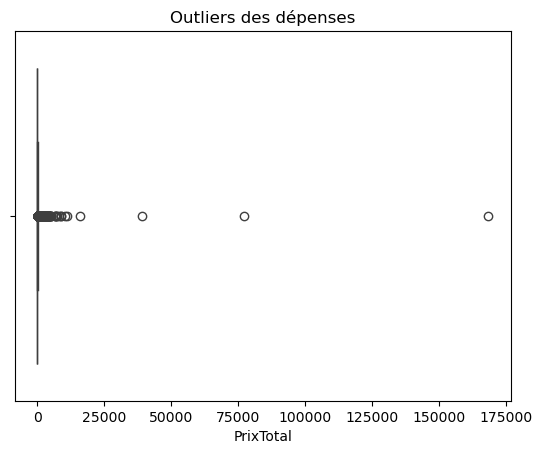

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,DateFacture,PrixTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12-01 07:45:00,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01 07:45:00,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01 07:45:00,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12-01 07:45:00,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01 07:45:00,30.0


In [8]:
# Supprimer les lignes où Customer ID est manquant
data = data.dropna(subset=['Customer ID'])

# Supprimer les doublons
data = data.drop_duplicates()

# Supprimer les factures annulées (commencent par 'C')
data = data[~data['Invoice'].astype(str).str.startswith('C')]

# Garder seulement les valeurs positives pour Quantity et Price
data = data[(data['Quantity'] > 0) & (data['Price'] > 0)]

# Conversion de la colonne date en datetime
data['DateFacture'] = pd.to_datetime(data['InvoiceDate'])

# Création d'une colonne PrixTotal pour chaque ligne
data['PrixTotal'] = data['Quantity'] * data['Price']

# Vérification des outliers dans les dépenses
sns.boxplot(x=data['PrixTotal'])
plt.title("Outliers des dépenses")
plt.show()

# Affichage des premières lignes pour vérifier
data.head()

In [10]:
# Date de référence pour calcul de la récence
date_reference = data['DateFacture'].max()

# Création des indicateurs par client
indicateurs = data.groupby('Customer ID').agg({
    'DateFacture': lambda x: (date_reference - x.max()).days,  # Récence
    'Invoice': 'nunique',                                       # Fréquence
    'PrixTotal': 'sum',                                         # Dépense totale
    'Quantity': 'mean',                                         # Taille moyenne du panier
    'StockCode': 'nunique'                                      # Diversité des articles
})

# Renommer les colonnes
indicateurs.columns = ['Recence', 'Frequence', 'Depense', 'TaillePanier', 'Diversite']

# Vérification
indicateurs.head()

,Recence,Frequence,Depense,TaillePanier,Diversite
Customer ID,,,,,
12346.0,325,12,77556.46,2184.852941,27
12347.0,1,8,4921.53,13.364865,126
12348.0,74,5,2019.40,53.215686,25
12349.0,18,4,4428.69,9.280000,138
12350.0,309,1,334.40,11.588235,17


In [12]:
# Standardisation des indicateurs pour le clustering
scaler = StandardScaler()
indicateurs_norm = scaler.fit_transform(indicateurs)

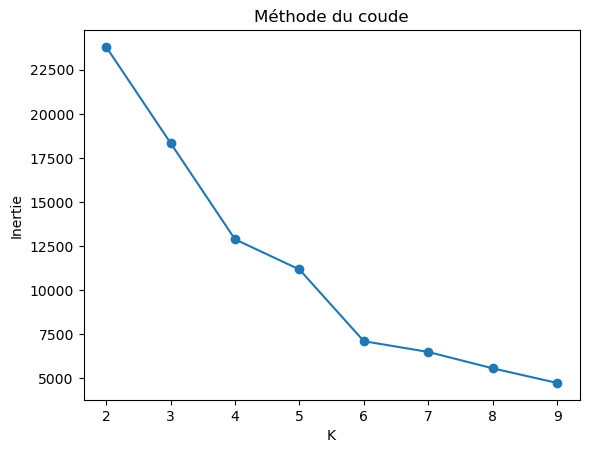

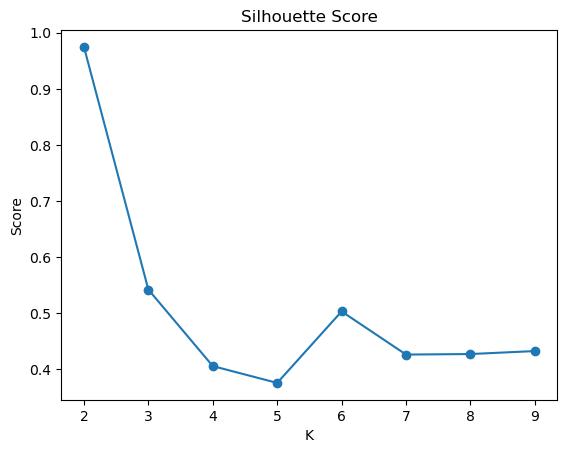

In [14]:
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(indicateurs_norm)
    
    inertia.append(km.inertia_)  # Méthode du coude
    silhouette_scores.append(silhouette_score(indicateurs_norm, labels))  # Score silhouette

# Graphique Méthode du coude
plt.plot(K_range, inertia, marker='o')
plt.title("Méthode du coude")
plt.xlabel("K")
plt.ylabel("Inertie")
plt.show()

# Graphique Score silhouette
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

In [57]:
# Clustering final avec K=3
kmeans = KMeans(n_clusters=3, random_state=42)
indicateurs['Cluster_KMeans'] = kmeans.fit_predict(indicateurs_norm)

# Vérification du score silhouette
score = silhouette_score(indicateurs_norm, indicateurs['Cluster_KMeans'])
print("Silhouette Score :", score)

# Analyse moyenne des clusters
print(indicateurs.groupby('Cluster_KMeans').mean())

Silhouette Score : 0.5419167067413441
                   Recence  Frequence        Depense  TaillePanier  \
Cluster_KMeans                                                       
0               223.180483   3.753816    1311.697086     20.851682   
1                 0.000000   2.000000  168472.500000  26999.000000   
2                32.182336  24.987179   14840.882259     19.828637   

                 Diversite  Cluster_CAH  
Cluster_KMeans                           
0                52.674010     1.000000  
1                 3.000000     2.000000  
2               298.206553     1.025641  


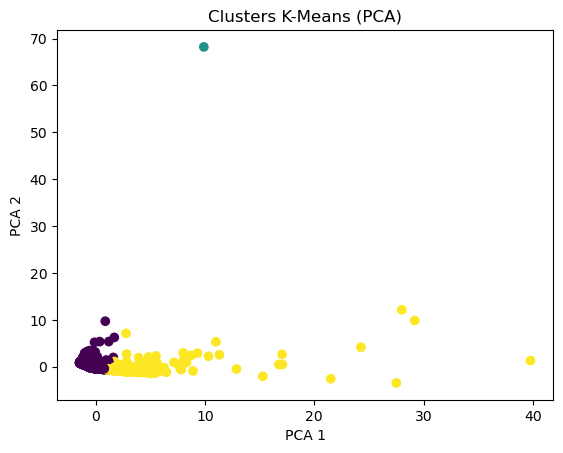

In [59]:
# PCA pour réduire à 2 dimensions
pca = PCA(n_components=2)
pca_data = pca.fit_transform(indicateurs_norm)

plt.scatter(pca_data[:,0], pca_data[:,1], c=indicateurs['Cluster_KMeans'])
plt.title("Clusters K-Means (PCA)")
plt.xlabel("PCA 1")  
plt.ylabel("PCA 2")   
plt.show()

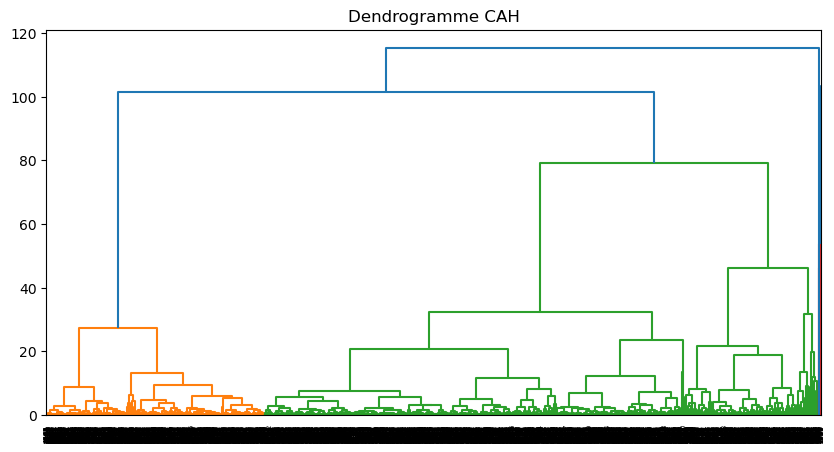

Cluster_CAH        1   2  3
Cluster_KMeans             
0               5175   0  0
1                  0   0  1
2                684  18  0
               Recence   Frequence        Depense  TaillePanier   Diversite  \
Cluster_CAH                                                                   
1            200.96467    5.836491    2347.609494     20.510992   79.400922   
2              5.50000  153.944444  191760.430000     91.847483  928.833333   
3              0.00000    2.000000  168472.500000  26999.000000    3.000000   

             Cluster_KMeans  
Cluster_CAH                  
1                  0.233487  
2                  2.000000  
3                  1.000000  


In [61]:
# Lien hiérarchique
Z = linkage(indicateurs_norm, method='ward')

# Dendrogramme
plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrogramme CAH")
plt.show()

# Attribution des clusters
indicateurs['Cluster_CAH'] = fcluster(Z, 3, criterion='maxclust')
print(pd.crosstab(indicateurs['Cluster_KMeans'], indicateurs['Cluster_CAH']))

print(indicateurs.groupby('Cluster_CAH').mean())

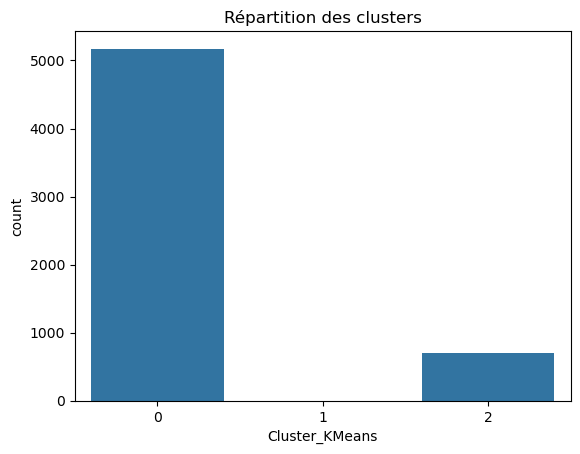

In [63]:
sns.countplot(x='Cluster_KMeans', data=indicateurs)
plt.title("Répartition des clusters")
plt.show()

In [65]:
basket = data.groupby(['Invoice', 'Description'])['Quantity']\
    .sum().unstack().fillna(0)

basket = (basket > 0).astype(int) # Binaire pour FP-Growth

In [66]:
print(basket)

Description    DOORMAT UNION JACK GUNS AND ROSES   3 STRIPEY MICE FELTCRAFT  \
Invoice                                                                       
489434                                         0                          0   
489435                                         0                          0   
489436                                         0                          0   
489437                                         0                          0   
489438                                         0                          0   
...                                          ...                        ...   
581583                                         0                          0   
581584                                         0                          0   
581585                                         0                          0   
581586                                         0                          0   
581587                                         0    

In [69]:
basket[basket.sum(axis=1) > 0]

Description,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,BROWN PIRATE TREASURE CHEST,Bank Charges,CAMPHOR WOOD PORTOBELLO MUSHROOM,CHERRY BLOSSOM DECORATIVE FLASK,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Invoice,,,,,,,,,,,,,,,,,,,,,
489434,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489435,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489436,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489437,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489438,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581583,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581584,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581585,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0


In [73]:
#عرض عدد مرات شراء كل منتج:
basket.sum().sort_values(ascending=False).head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    4888
REGENCY CAKESTAND 3 TIER              3317
ASSORTED COLOUR BIRD ORNAMENT         2652
JUMBO BAG RED RETROSPOT               2612
PARTY BUNTING                         2077
LUNCH BAG  BLACK SKULL.               1997
LUNCH BAG SPACEBOY DESIGN             1874
REX CASH+CARRY JUMBO SHOPPER          1857
HOME BUILDING BLOCK WORD              1831
STRAWBERRY CERAMIC TRINKET BOX        1818
dtype: int64

In [32]:
# Création basket binaire avec type bool
basket_bool = basket.astype(bool)

# FP-Growth
articles_frequents = fpgrowth(basket_bool, min_support=0.01, use_colnames=True)

# Règles d'association
regles = association_rules(articles_frequents, metric="lift", min_threshold=1)

# Filtrage règles intéressantes
regles = regles[(regles['lift'] > 1.2) & (regles['confidence'] > 0.5)]

# Top 10 règles
regles.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
376,(POPPY'S PLAYHOUSE LIVINGROOM ),(POPPY'S PLAYHOUSE BEDROOM ),0.012443,0.015040,0.010333,0.830435,55.216445,1.0,0.010146,5.808741,0.994261,0.602524,0.827846,0.758743
377,(POPPY'S PLAYHOUSE BEDROOM ),(POPPY'S PLAYHOUSE LIVINGROOM ),0.015040,0.012443,0.010333,0.687050,55.216445,1.0,0.010146,3.155642,0.996882,0.602524,0.683107,0.758743
374,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE LIVINGROOM ),0.016663,0.012443,0.011036,0.662338,53.230350,1.0,0.010829,2.924688,0.997840,0.610778,0.658083,0.774647
375,(POPPY'S PLAYHOUSE LIVINGROOM ),(POPPY'S PLAYHOUSE KITCHEN),0.012443,0.016663,0.011036,0.886957,53.230350,1.0,0.010829,8.698754,0.993577,0.610778,0.885041,0.774647
373,(POPPY'S PLAYHOUSE BEDROOM ),(POPPY'S PLAYHOUSE KITCHEN),0.015040,0.016663,0.012767,0.848921,50.947655,1.0,0.012517,6.508757,0.995342,0.674286,0.846361,0.807577
372,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE BEDROOM ),0.016663,0.015040,0.012767,0.766234,50.947655,1.0,0.012517,4.213442,0.996984,0.674286,0.762664,0.807577
133,(SET/6 RED SPOTTY PAPER PLATES),(SET/6 RED SPOTTY PAPER CUPS),0.018718,0.016798,0.013227,0.706647,42.067710,1.0,0.012913,3.351605,0.994851,0.593447,0.701636,0.747044
132,(SET/6 RED SPOTTY PAPER CUPS),(SET/6 RED SPOTTY PAPER PLATES),0.016798,0.018718,0.013227,0.787440,42.067710,1.0,0.012913,4.616484,0.992908,0.593447,0.783385,0.747044
161,"(KEY FOB , SHED)","(KEY FOB , BACK DOOR )",0.017690,0.015554,0.011253,0.636086,40.896434,1.0,0.010978,2.705160,0.993117,0.511685,0.630336,0.679782
160,"(KEY FOB , BACK DOOR )","(KEY FOB , SHED)",0.015554,0.017690,0.011253,0.723478,40.896434,1.0,0.010978,3.552377,0.990961,0.511685,0.718498,0.679782


In [34]:
# Ajouter le cluster KMeans à la table originale
data = data.merge(indicateurs[['Cluster_KMeans']], on='Customer ID')

In [38]:
for c in data['Cluster_KMeans'].unique():
    print(f"\nCluster {c}")

    cluster_data = data[data['Cluster_KMeans'] == c]

    # Création du panier cluster
    basket_c = cluster_data.groupby(['Invoice', 'Description'])['Quantity']\
        .sum().unstack().fillna(0)

    # Transformation en booléen (True si acheté, False sinon)
    basket_c = basket_c.astype(bool)

    # FP-Growth
    freq = fpgrowth(basket_c, min_support=0.01, use_colnames=True)
    rules = association_rules(freq, metric="lift", min_threshold=1)

    # Filtrage règles intéressantes
    rules = rules[(rules['lift'] > 1.2) & (rules['confidence'] > 0.5)]

    # Top 5 règles par cluster
    print(rules.sort_values(by='lift', ascending=False).head(5))


Cluster 0
                                           antecedents  \
63                     (SET/6 RED SPOTTY PAPER PLATES)   
62                       (SET/6 RED SPOTTY PAPER CUPS)   
159                       (POPPY'S PLAYHOUSE BEDROOM )   
158                        (POPPY'S PLAYHOUSE KITCHEN)   
140  (GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...   

                          consequents  antecedent support  consequent support  \
63      (SET/6 RED SPOTTY PAPER CUPS)            0.013847            0.012766   
62    (SET/6 RED SPOTTY PAPER PLATES)            0.012766            0.013847   
159       (POPPY'S PLAYHOUSE KITCHEN)            0.012972            0.014208   
158      (POPPY'S PLAYHOUSE BEDROOM )            0.014208            0.012972   
140  (PINK REGENCY TEACUP AND SAUCER)            0.016627            0.017193   

      support  confidence       lift  representativity  leverage  conviction  \
63   0.010501    0.758364  59.403166               1.0  0.010325    4.085

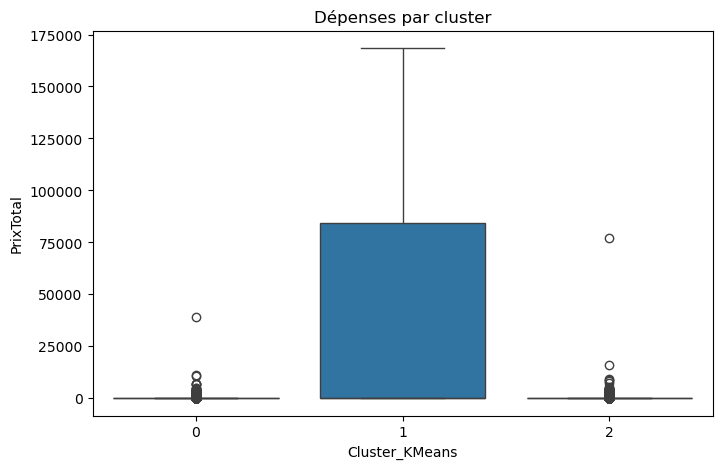

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster_KMeans', y='PrixTotal', data=data)
plt.title("Dépenses par cluster")
plt.show()